In [1]:
#Import all packages
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium
import contextily as ctx
import scipy.stats
import scipy.interpolate
import tqdm
from pathlib import Path
import xarray as xr
import skgstat as skg
import seaborn as sns
import pysal
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import moran_scatterplot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib_scalebar.scalebar import ScaleBar
import rasterio
from rasterio.plot import show

/opt/conda/lib/python3.11/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [6]:
DATA = Path("/home/jovyan/Society_of_Bouy_Cowboys/Data")

NETCDF = DATA / "NET_CDF"
ICE = DATA / "Ice_edge"
SAT = DATA / "SAT_GeoTiff"

raster_file = SAT / "IcyCape_201911201739_S1B_EW_50m.tif"
edge_file = ICE / "ice_edge_11201739.geojson"

# buoy files
moor_files = {
    "S1P1": NETCDF / "S1P1.nc",
    "S1P2": NETCDF / "S1P2.nc",
    "S1P3": NETCDF / "S1P3.nc",
    "S1A1": NETCDF / "S1A1.nc"
}


In [7]:
def get_mooring_latlon(ncfile):
    ds = xr.open_dataset(ncfile)

    lat = np.asarray(ds["lat_lagrangian"]).astype(float).ravel()
    lon = np.asarray(ds["lon_lagrangian"]).astype(float).ravel()

    good = np.isfinite(lat) & np.isfinite(lon)

    lat = lat[good]
    lon = lon[good]

    if len(lat) == 0:
        raise ValueError(f"No valid lat/lon found in {ncfile}")

    # median gives robust representative location
    return np.median(lat), np.median(lon)

In [9]:
rows = []

for name, fn in moor_files.items():
    lat, lon = get_mooring_latlon(fn)
    rows.append({
        "source": name,
        "lat": lat,
        "lon": lon
    })

moor_df = pd.DataFrame(rows)

moor_df

,source,lat,lon
0,S1P1,70.34613,-162.05704
1,S1P2,70.39473,-162.13675
2,S1P3,70.43995,-162.20300
3,S1A1,70.48695,-162.28278


In [13]:
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

# ---------------------------------------------------------------------------
# UTM Zone 4N projection  —  EPSG:32604  WGS84 / UTM Zone 4N
# Same function used in the GeoTIFF conversion script
# ---------------------------------------------------------------------------

def utm_fwd(lon_deg, lat_deg, zone=4):
    """WGS84 lon/lat (degrees) -> UTM Zone 4N easting/northing (metres)."""
    a   = 6378137.0
    f   = 1 / 298.257223563
    e2  = 2*f - f**2
    ep2 = e2 / (1 - e2)
    k0  = 0.9996
    E0  = 500000.0

    lam0 = np.radians(-180 + (zone - 1)*6 + 3)

    phi = np.radians(lat_deg)
    lam = np.radians(lon_deg)

    N  = a / np.sqrt(1 - e2 * np.sin(phi)**2)
    T  = np.tan(phi)**2
    C  = ep2 * np.cos(phi)**2
    A_ = np.cos(phi) * (lam - lam0)

    e4 = e2**2;  e6 = e2**3
    M  = a * ((1 - e2/4 - 3*e4/64 - 5*e6/256)   * phi
              - (3*e2/8 + 3*e4/32 + 45*e6/1024)  * np.sin(2*phi)
              + (15*e4/256 + 45*e6/1024)          * np.sin(4*phi)
              - (35*e6/3072)                       * np.sin(6*phi))

    x = k0*N*(A_ + (1 - T + C)*A_**3/6
              + (5 - 18*T + T**2 + 72*C - 58*ep2)*A_**5/120) + E0
    y = k0*(M + N*np.tan(phi)*(A_**2/2
              + (5 - T + 9*C + 4*C**2)*A_**4/24
              + (61 - 58*T + T**2 + 600*C - 330*ep2)*A_**6/720))
    return x, y


# ---------------------------------------------------------------------------
# Convert moor_df lat/lon to UTM x/y
# ---------------------------------------------------------------------------

xs, ys = utm_fwd(moor_df["lon"].values, moor_df["lat"].values)

moor_32604 = gpd.GeoDataFrame(
    moor_df,
    geometry=[Point(x, y) for x, y in zip(xs, ys)],
    crs="EPSG:32604"
)

print(moor_32604[["source", "lat", "lon", "geometry"]])

  source       lat        lon                        geometry
0   S1P1  70.34613 -162.05704  POINT (385288.486 7807356.202)
1   S1P2  70.39473 -162.13675   POINT (382579.19 7812922.164)
2   S1P3  70.43995 -162.20300  POINT (380366.746 7818088.386)
3   S1A1  70.48695 -162.28278  POINT (377672.412 7823482.254)


Bounds: x=332083.7 to 437432.4, y=7755199.9 to 7860460.5


Text(0.5, 1.0, 'Icy Cape SAR with Moorings')

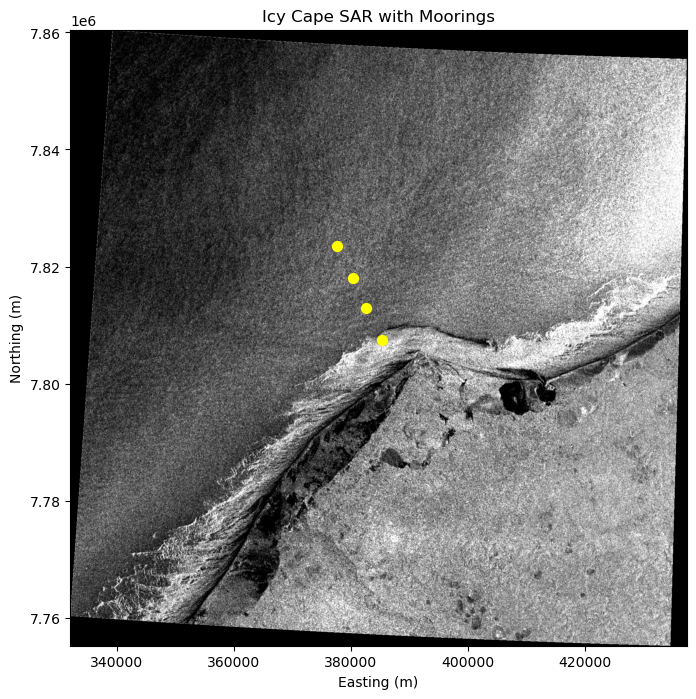

In [18]:
import tifffile
import struct

with tifffile.TiffFile(raster_file) as tif:
    data   = tif.asarray()
    page   = tif.pages[0]
    tags   = {t.code: t for t in page.tags.values()}

    # Read georeferencing
    scale    = struct.unpack('<3d', tags[33550].value)
    tp       = struct.unpack('<6d', tags[33922].value)
    x_min    = tp[3]
    y_max    = tp[4]
    x_max    = x_min + scale[0] * data.shape[-1]
    y_min    = y_max - scale[1] * data.shape[-2]

print(f"Bounds: x={x_min:.1f} to {x_max:.1f}, y={y_min:.1f} to {y_max:.1f}")

# Plot with correct extent
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(data[1], cmap="gray",
          extent=[x_min, x_max, y_min, y_max],
          origin="upper")

# Plot mooring points — already in EPSG:32604
moor_32604.plot(ax=ax, color="yellow", markersize=50, zorder=5, label="Moorings")


ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Icy Cape SAR with Moorings")

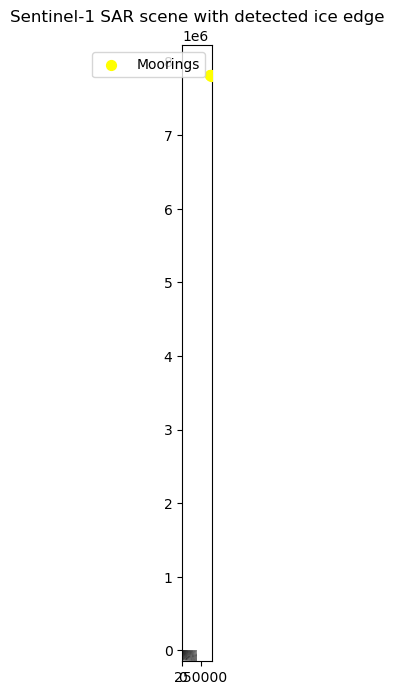

In [12]:
fig, ax = plt.subplots(figsize=(10,8))

with rasterio.open(raster_file) as src:

   # print("Raster bounds:", src.bounds)
   # print("Raster CRS:", src.crs)

    show(src, ax=ax, cmap="gray")



moor_32604.plot(ax=ax, color="yellow", markersize=50, zorder=5, label="Moorings")

ax.set_title("Sentinel-1 SAR scene with detected ice edge")

ax.legend()

NameError: name 'ds' is not defined

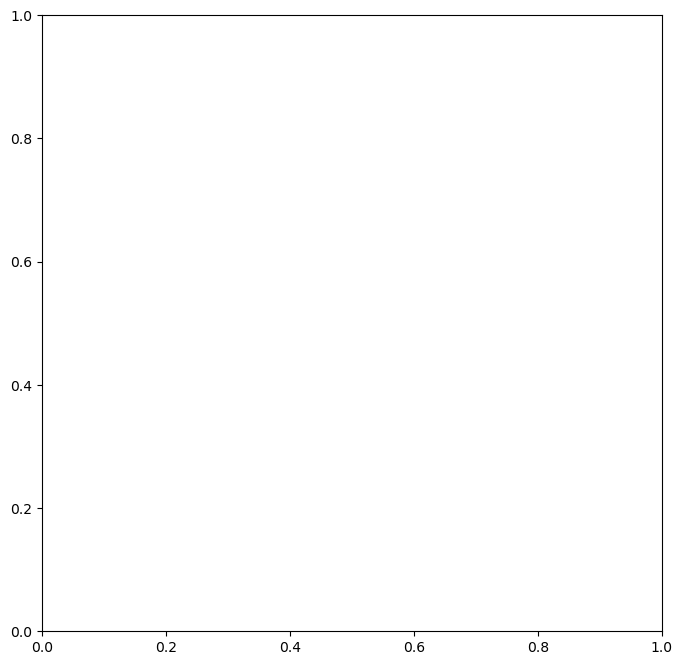

In [1]:
# Time Elapse code

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 8))

def update(i):
    ax.clear()
    ds["SAR_backscatter"].isel(time=i).plot(ax=ax, cmap="gray", add_colorbar=False)
    moor_gdf.plot(ax=ax, color="yellow", markersize=50, zorder=5, label="Moorings")
    # Label each mooring
    for _, row in moor_gdf.iterrows():
        ax.annotate(row["source"],
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(5, 5), textcoords="offset points",
                    color="yellow", fontsize=8)
    ax.set_title(str(ds.time.values[i])[:16])
    ax.legend(loc="lower right")

ani = animation.FuncAnimation(
    fig, update, frames=len(ds.time), interval=500
)

plt.close()
HTML(ani.to_jshtml())